# Wavelet
*  Jose Gonzalez Lopez
*  Mykola Liashuha

# Introduction
In this notebook we will be applying some denoising techniques in the wavelet basis. We will first create some noise data as we did on the previous exercise and then we will try to recover the original data by applying hard or soft thresholding to the image.

# Imports

In [1]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise

from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

In [2]:
#Numerical tools imports
from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
%load_ext autoreload
%autoreload 2
%pylab inline
%matplotlib inline

Populating the interactive namespace from numpy and matplotlib


/home/mykola/anaconda3/envs/nets/lib/python3.6/site-packages/IPython/core/magics/pylab.py:160: UserWarning: pylab import has clobbered these variables: ['pylab']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


# Auxiliar Functions

In [3]:
'''
Signal-to-noise ratio
x: original signal
y: changed(noisy) signal
'''
def snr(x, y):
#     return 20*np.log10(np.linalg.norm(x)/np.linalg.norm(x-y))
    return 20*np.log10(np.sqrt(np.power(x, 2).sum())/np.sqrt(np.power(x-y, 2).sum()))

In [4]:
'''
Hard thesholding operator
u: image in wavelet basis
t: threshold value
'''
def thresh_hard(u,t):
    return u*(abs(u)>t)

'''
Soft thresholding operator
u: image in wavelet basis
t: threshold value
'''
def thresh_soft(u,t):
    return maximum(1-t/abs(u), 0)*u

# Loading data

Below we load the image, but most importatnly we keep it in range [0,1]

In [5]:
img = cv2.imread('barbara.jpg')
gray = np.array(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
gray = gray / 255.


In order to show further the process of denoising we create image with different levels of noise.

In [6]:
stds = [0.42,0.25, 0.16, 0.08, 0.04]#[130,70,40, 24,13]
noisy_imgs=[]
for std in stds:
    noise = numpy.random.normal(0, 1, size=gray.shape)
    img_noise = gray + std*noise
    noisy_imgs.append(img_noise)

# Hard thresholding in wavelet basis

Below you are able to see how the values would be affected by filter with hard threshold.

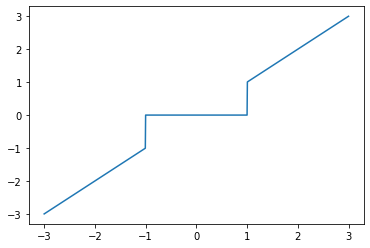

In [7]:
T = 1
alpha = np.linspace(-3,3,1000);

plt.plot(alpha, alpha*(np.abs(alpha)>T))

Then we define parameters for othogonal wavelet transoform.

In [8]:
h = [0, .482962913145, .836516303738, .224143868042, -.129409522551]
h = h/norm(h)
Jmin = 2

We will add some noisy to the image and define the threshold value for hard-threshold filter.

In [9]:
sigma = 0.16

noise = numpy.random.normal(0, 1, size=gray.shape)
img_noise = gray + sigma*noise
T = 3*sigma


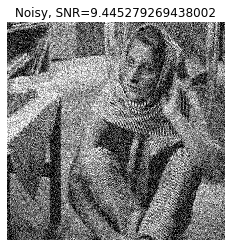

In [10]:
imageplot(clamp(img_noise), 'Noisy, SNR=' + str(snr(gray,img_noise)) )

We can see that the image looks highly noisy. Therefore in order to perform denoising, we are going to apply wavelet orthogonal transform to the image and transform it to wavelet basis.

In [11]:
a = perform_wavortho_transf(img_noise,Jmin,+1,h)

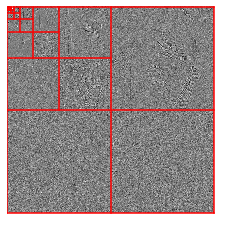

In [12]:
plot_wavelet(a,Jmin);

Having image in wavelet basis we are going to apply hard thresholding to obtained values.

In [13]:
aT = thresh_hard(a, T)

array([[0.24459532, 0.        , 0.21416997, ..., 0.5       , 0.5       ,
        0.5       ],
       [0.1546307 , 0.60568724, 1.        , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.50564446, 0.74062973, 0.73187438, ..., 0.5       , 0.5       ,
        0.5       ],
       ...,
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ]])

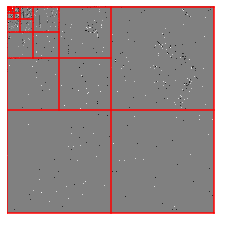

In [14]:
plot_wavelet(aT,Jmin)

And after applying hard thresholding we are to to transofrm image back to its original basis.

In [15]:
fHard = perform_wavortho_transf(aT,Jmin,-1,h)

Original Image


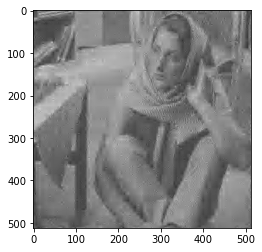

In [16]:
print('Original Image')
plt.imshow(fHard, cmap='gray')
plt.show()

Noisy image


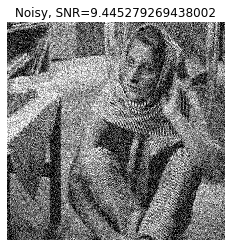

In [17]:
print('Noisy image')
imageplot(clamp(img_noise), 'Noisy, SNR=' + str(snr(gray,img_noise)) )

Denosied image


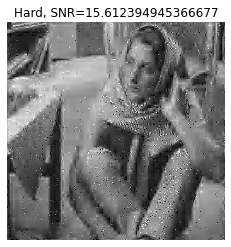

In [18]:
print('Denosied image')
imageplot(clamp(fHard), 'Hard, SNR=' + str(snr(gray,fHard)) )

As you see from the experiment, the denosied image has much less noise (since Signal-noise-ratio increased).

Moreover, in order to show that the denoising pipeline works we are going to test on several images with different level of noise.

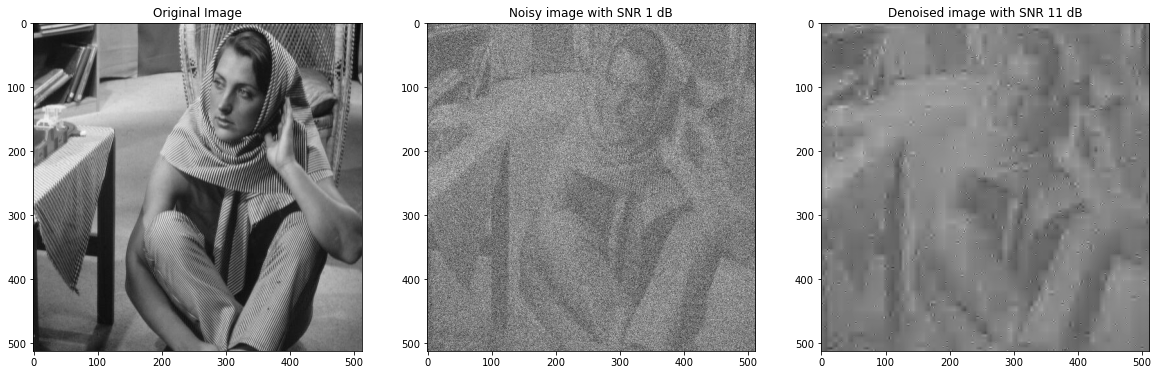

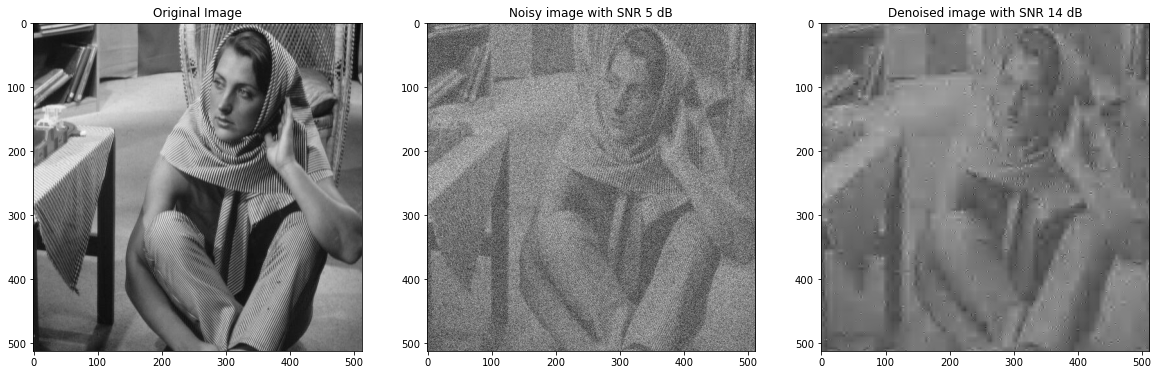

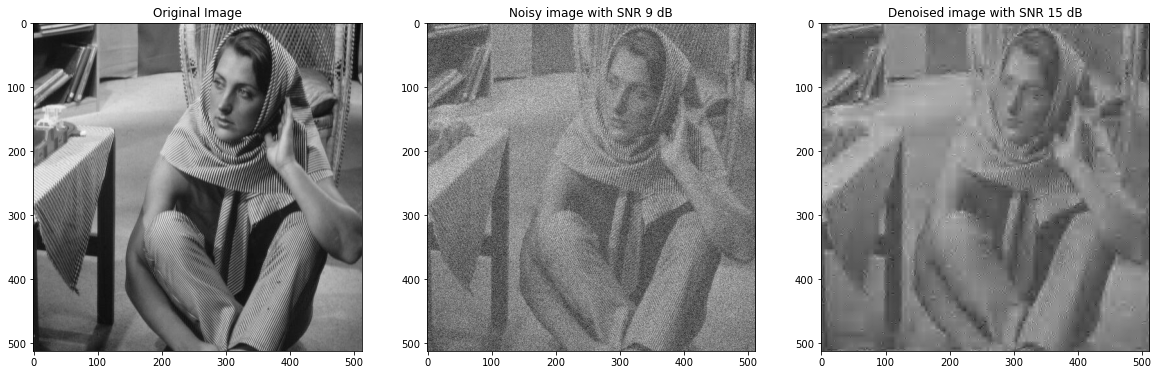

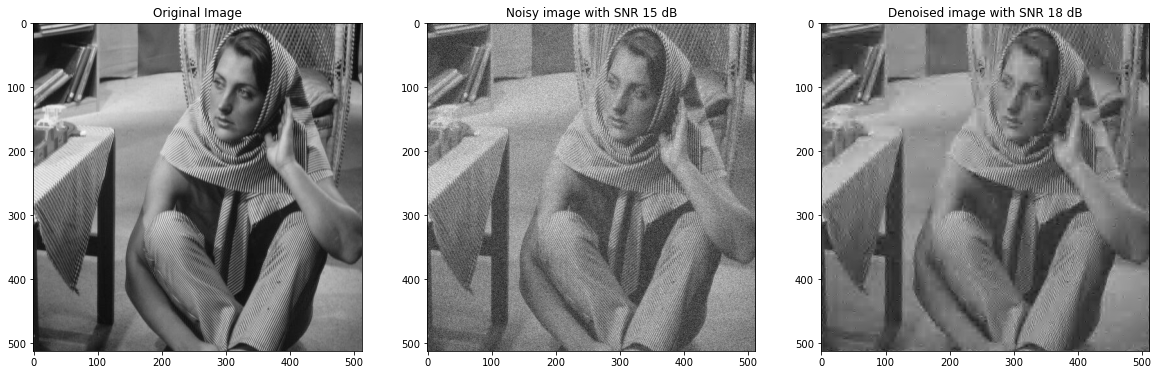

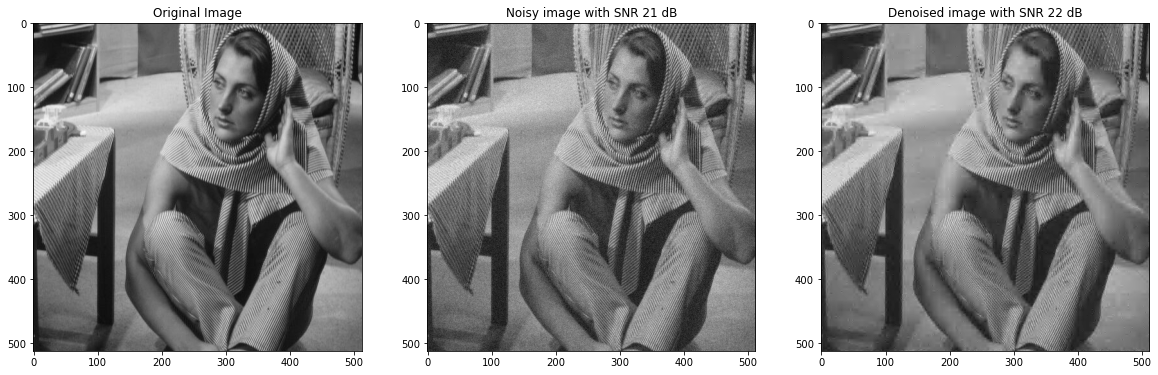

In [19]:

for i, noisy_image in enumerate(noisy_imgs):
    std = stds[i]
    T = 3*std
    
    a = perform_wavortho_transf(noisy_image,Jmin,+1,h)
    aT = thresh_hard(a, T)
    fHard = perform_wavortho_transf(aT,Jmin,-1,h)
    
    fig, axs = plt.subplots(1, 3)
    fig.set_figheight(20)
    fig.set_figwidth(20)
    axs[0].imshow(gray,cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].imshow(noisy_image,cmap='gray')
    axs[1].set_title('Noisy image'+f' with SNR {int(snr(gray,noisy_image))} dB')
    axs[2].imshow(fHard,cmap='gray')
    axs[2].set_title('Denoised image'+f' with SNR {int(snr(gray,fHard))} dB')
    plt.show()

# Soft thresholding in wavelet basis

As well, we are going to provide another way for thresholding the image: Soft-thresholding. Below you can see plot how values are going to be affected by aplying soft-thresholding.

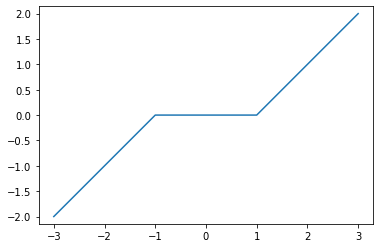

In [20]:
alpha = linspace(-3,3,1000)
plot(alpha, thresh_soft(alpha,1))
axis('equal');

Below we are going perform another experiment applying soft-thresholding to an image. And we start from creating noisy image.

In [21]:
sigma = 0.08

noise = numpy.random.normal(0, 1, size=gray.shape)
img_noise = gray + sigma*noise

T = (1.6)*sigma

Futher we are going to applying soft-thresholding to an image in wavelet basis and transofrm it back to ususal usual basis.

In [22]:
a = perform_wavortho_transf(img_noise,Jmin,+1,h)
aT = thresh_soft(a,T)
aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
fSoft = perform_wavortho_transf(aT,Jmin,-1,h)

Nosiy image


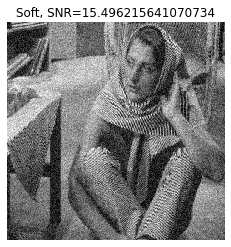

In [23]:
print('Nosiy image')
imageplot(clamp(img_noise), 'Soft, SNR=' + str(snr(gray,img_noise)) )

Denoised image


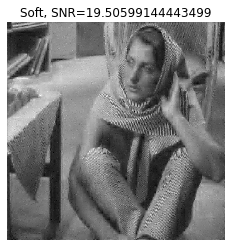

In [24]:
print('Denoised image')
imageplot(clamp(fSoft), 'Soft, SNR=' + str(snr(gray,fSoft)) )

As well as before, we are going to apply soft-thresholding to images with different level of noise.

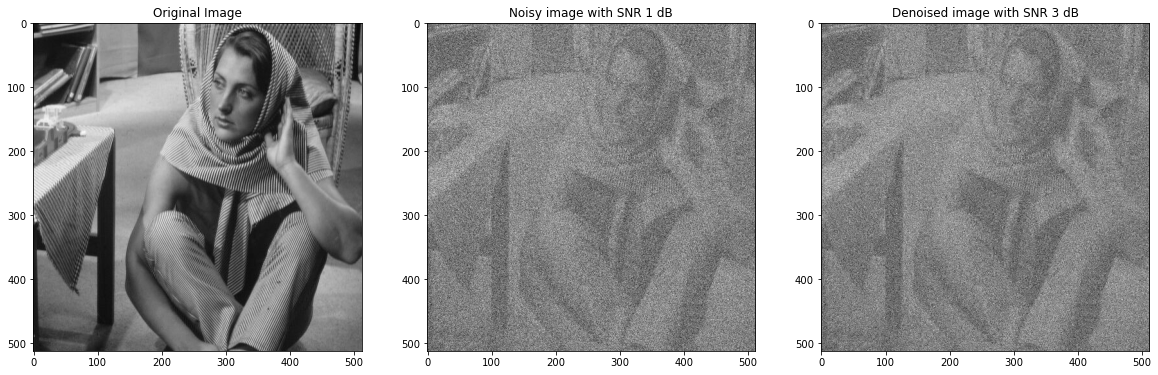

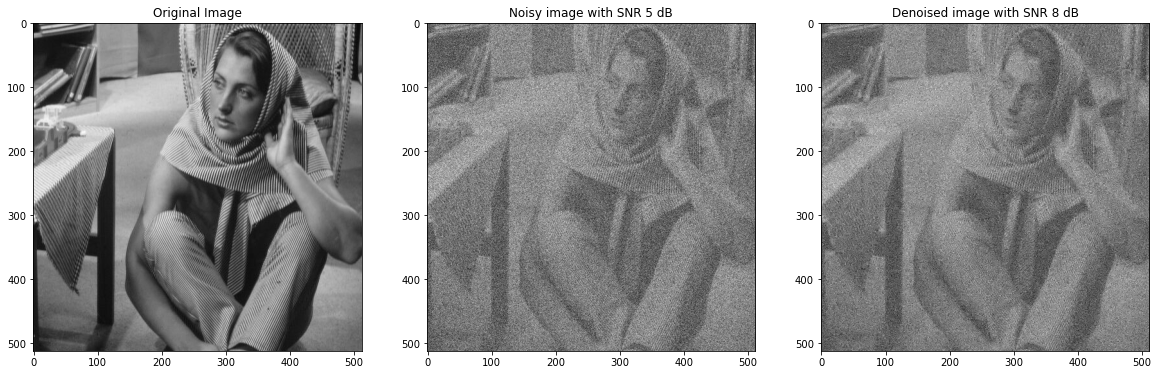

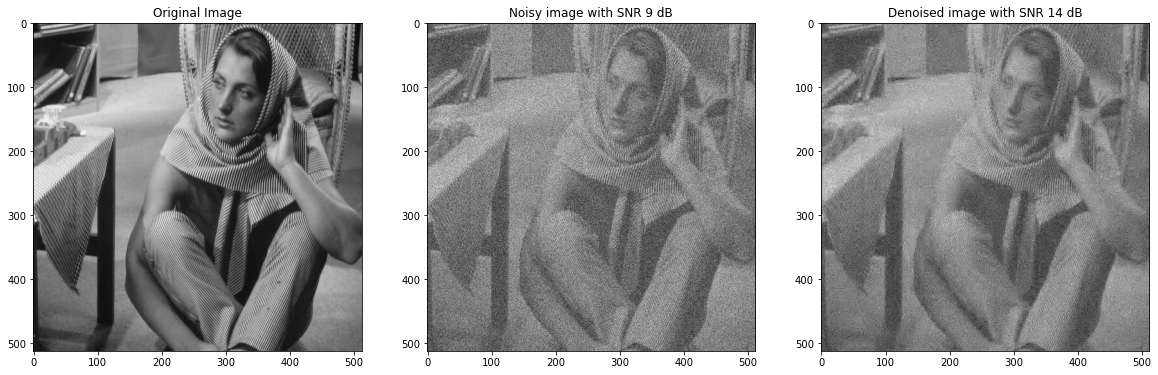

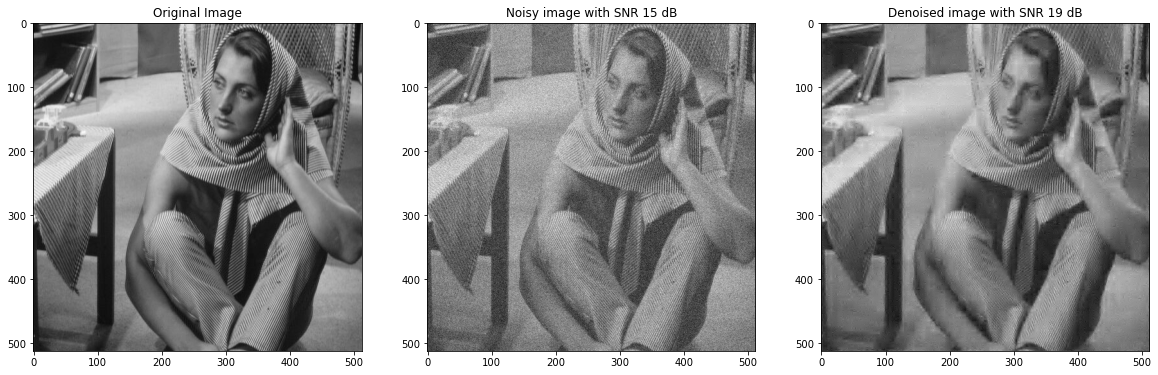

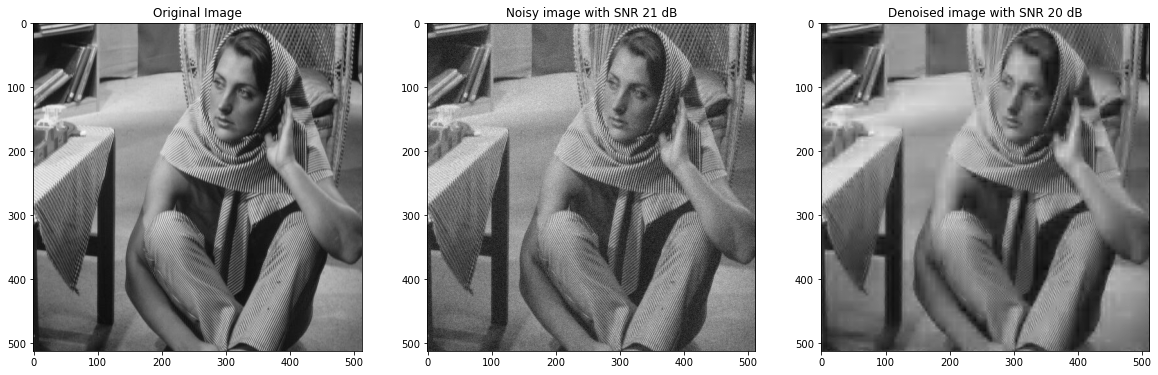

In [25]:

for i, noisy_image in enumerate(noisy_imgs):
    std = stds[i]
    T = (1.5)*sigma
    
    a = perform_wavortho_transf(noisy_image,Jmin,+1,h)
    aT = thresh_soft(a,T)
    aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
    fSoft = perform_wavortho_transf(aT,Jmin,-1,h)
    
    fig, axs = plt.subplots(1, 3)
    fig.set_figheight(20)
    fig.set_figwidth(20)
    axs[0].imshow(gray,cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].imshow(noisy_image,cmap='gray')
    axs[1].set_title('Noisy image'+f' with SNR {int(snr(gray,noisy_image))} dB')
    axs[2].imshow(fSoft,cmap='gray')
    axs[2].set_title('Denoised image'+f' with SNR {int(snr(gray,fSoft))} dB')
    plt.show()

# Finding best threshold

Below we are going to plot SNR and corresponding threshold values for hard and soft thresholding.

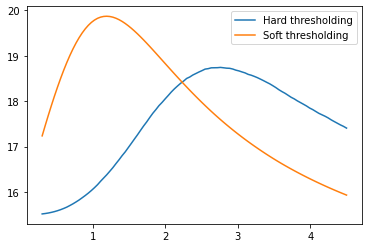

In [26]:
sigma = 0.08
ran = np.linspace(0.3, 4.5, num=100)*sigma

hard = []
soft = []

for T in ran:
    a = perform_wavortho_transf(img_noise,Jmin,+1,h)
    
    #hard
    aT = thresh_hard(a, T)
    fHard = perform_wavortho_transf(aT,Jmin,-1,h)
    hard.append(snr(gray,fHard))
    
    #soft
    aT = thresh_soft(a,T)
    aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
    fSoft = perform_wavortho_transf(aT,Jmin,-1,h)
    soft.append(snr(gray,fSoft))
    
plt.plot(ran/sigma, hard, label='Hard thresholding')
plt.plot(ran/sigma, soft, label='Soft thresholding')
plt.legend()
plt.show()

As you can observe, we have achieved different SNR values after applying denoising with differnt threshold values. From this plot it is easy to identify best threshold parameters:


In [27]:
best_hard = np.argmax(hard)
best_soft = np.argmax(soft)
print('Best hard-thresholding parameter', ran[best_hard]/sigma)
print('Best soft-thresholding parameter', ran[best_soft]/sigma)

Best hard-thresholding parameter 2.7606060606060607
Best soft-thresholding parameter 1.190909090909091


Denoised image with best threshold value


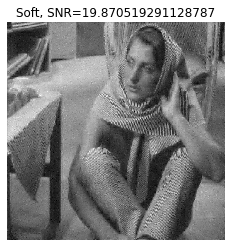

In [28]:
sigma = 0.08

noise = numpy.random.normal(0, 1, size=gray.shape)
img_noise = gray + sigma*noise

T = 1.19*sigma
aT = thresh_soft(a,T)
aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
fSoft = perform_wavortho_transf(aT,Jmin,-1,h)

print('Denoised image with best threshold value')
imageplot(clamp(fSoft), 'Soft, SNR=' + str(snr(gray,fSoft)) )

As you see, after choosing the right threshold value the image might be denosied in much better way.

# Translation invariant denoising

One of the problems of orthogonal wavelet transform is that it is provide different results for the same images, but translated ones. So it this kind of transform is not translation invariant.

In order to overcome this drawback we are going to:
- transform image with orthogonal wavelet transform to all circle-shifted copies of an image
- apply denoising procedure to each image copy
- apply circle-shift to each denoised copied back to normal orientation
- average results from all denoised copies
- transform resulting image back to normal basis.



We would have m different states of circle-shift in both direction. And we would prepare combinations of all m * m possible combinations.

In [32]:
m = 4
[dY,dX] = meshgrid(arange(0,m),arange(0,m))
delta = concatenate( (dX.reshape(m*m,1), dY.reshape(m*m,1)), axis=1)


Finally we would apply $m^2$ number of iterations of the folowwing pipeline.

In [33]:
sigma = 0.08

noise = numpy.random.normal(0, 1, size=gray.shape)
img_noise = gray + sigma*noise

n = gray.shape[0]
fTI = zeros([n,n])
T = 3*sigma
for i in arange(0,m*m):
    fS = circshift(img_noise,delta[i,:])
    a = perform_wavortho_transf(fS,Jmin,1,h)
    aT = thresh_hard(a,T)
    fS = perform_wavortho_transf(aT,Jmin,-1,h)
    fS = circshift(fS,-delta[i,:])
    fTI = i/(i+1.0)*fTI + 1.0/(i+1)*fS

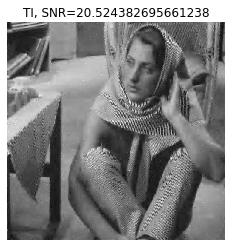

In [34]:
imageplot(clamp(fTI), 'TI, SNR=' + str(snr(gray,fTI)) )


As you see from results the translation invariant soft thresholding pipeline gave a benefit of having better denoising comparing to basic Hard- and Soft-thresholding. Moreover, by finding the correct threshold balue for this approach, the results can be even better as it was shown before.

# Conclusions


During this we have experimetned and implemented Hard, Soft and Translation Invariant Soft denoising algorthms. One of the most important aspects we found out are the threshold values in all kind of threshold denoising. Finally but not less importantly, these approaches gave us an understanding of how denoising in wavelet basis can be achieved.